Training RMSE: 68329.87371986113
Testing RMSE: 69830.43079478048


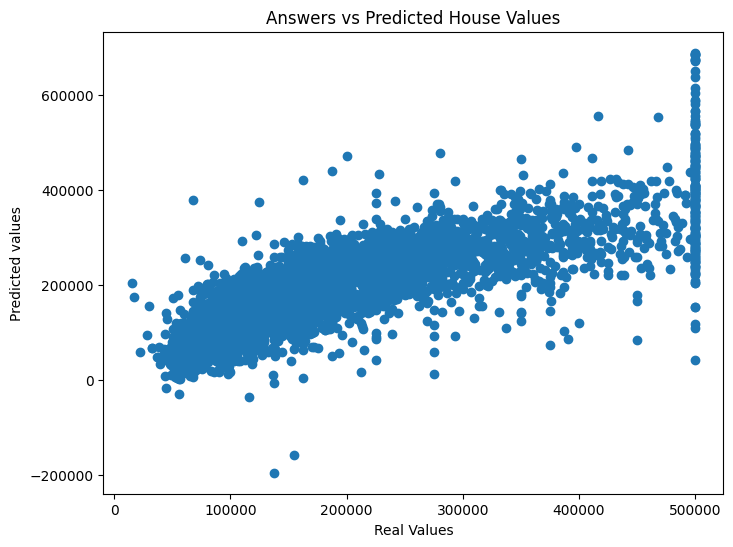

In [63]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

housing_df = pd.read_csv("housing.csv")
housing_df.head()

housing_df.isna().any()

housing_df['total_bedrooms'] = housing_df['total_bedrooms'].fillna(housing_df['total_bedrooms'].median())
housing_df["rooms_perhousehold"] = housing_df["total_rooms"] / housing_df["households"]
housing_df["population_per_household"] = housing_df['population'] / housing_df["households"]

housing_df.describe()

X_house = housing_df.drop(columns='median_house_value')
y = housing_df['median_house_value']

X_house = pd.get_dummies(X_house, columns=["ocean_proximity"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_house, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

train_pred = model.predict(X_train_scaled)
test_pred = model.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

plt.figure(figsize=(8,6))
plt.scatter(y_test, test_pred)
plt.xlabel("Real Values")
plt.ylabel("Predicted values")
plt.title("Answers vs Predicted House Values")
plt.show()

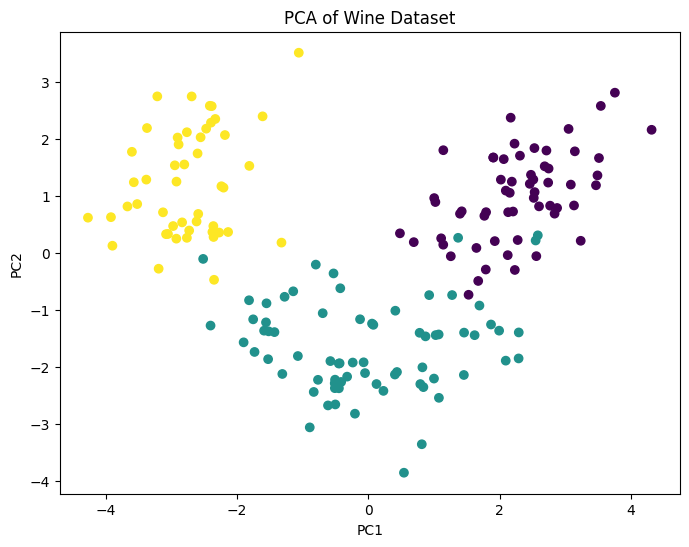

Number components of 85% variance: 1


In [64]:
from sklearn.decomposition import PCA

wine_df = pd.read_csv("Wine.csv")
wine_df.head()
wine_df.describe()
wine_df.isna().any()

X_wine = wine_df.iloc[:, 1:]

scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_wine_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Class_label"] = wine_df.iloc[:, 0]

plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["Class_label"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Wine Dataset")
plt.show()

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
num_components = np.argmax(cumulative_variance >= 0.85) + 1
print("Number components of 85% variance:", num_components)